<a href="https://colab.research.google.com/github/joaojesus2/lia1_2026_2-/blob/main/Atividade_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 Construção de um Modelo de Inteligência Artificial para Análise de Sentimentos em Textos (Ponta a Ponta)

---

## 🧠 Contextos de Aplicação no Mundo Real

🔹 **Gestão de Produtos e Feedback de Beta Testers:** Automatizar a leitura e triagem de milhares de comentários, relatórios de bugs e avaliações enviados por testadores em lojas de aplicativos. Isso permite aos engenheiros e gerentes priorizar correções críticas com base no volume de frustração dos usuários.

🔹 **Monitoramento de Marca e Social Listening:** Classificar menções espontâneas, tweets e postagens em redes sociais para medir a satisfação do público em tempo real diante de novos lançamentos ou campanhas de marketing.

🔹 **Suporte ao Cliente Inteligente:** Integrar modelos de PLN (Processamento de Linguagem Natural) em centrais de atendimento para detectar clientes extremamente irritados em chamados de suporte, direcionando-os imediatamente para atendimento humano prioritário.

---

## ⚙️ O Pipeline de um Projeto de Inteligência Artificial

$$\text{Coleta de Dados} \rightarrow \text{Pré-processamento} \rightarrow \text{Vetorização} \rightarrow \text{Arquitetura Neural} \rightarrow \text{Treinamento} \rightarrow \text{Validação} \rightarrow \text{Teste} \rightarrow \text{Inferência Real}$$

✨ *O verdadeiro valor na engenharia de machine learning não está apenas no dataset em si, mas na capacidade técnica de dominar e reaplicar o mesmo pipeline completo em diferentes problemas do ecossistema corporativo!* ✨

Neste notebook prático, vamos construir um modelo de IA especializado em processar sequências textuais. Utilizaremos o clássico dataset **IMDB** para ensinar a rede neural a ler uma crítica de texto livre e classificar automaticamente o sentimento subjacente entre **Positivo 🟢** ou **Negativo 🔴**.

> ⚠️ **Nota Linguística Importante:** Como o dataset de treino é composto exclusivamente por resenhas de cinema em **inglês**, o modelo apresenta excelente acurácia e robustez nesse idioma. Caso você digite frases em outro idioma (como o português), o modelo tentará interpretá-las, mas sem suporte nativo, gerando previsões baseadas apenas em padrões aproximados.

---

## 📋 Estrutura e Roteiro deste Notebook

1. **Setup e Importação de Bibliotecas:** Configuração do ambiente e declaração de hiperparâmetros globais.
2. **Carga e Exploração de Dados:** Download do IMDB e inspeção de tensores e dicionários textuais.
3. **Pré-processamento e Uniformização (*Padding*):** Padronização do comprimento das sequências de palavras.
4. **Construção da Arquitetura do Modelo:** Montagem da rede neural combinando camadas de *Embedding*, *Bidirectional LSTM* e *Dropout*.
5. **Treinamento e Validação Supervisionada:** Execução do aprendizado com monitoramento de perdas e *Early Stopping*.
6. **Avaliação de Desempenho e Métricas:** Análise profunda por meio de curvas de aprendizado, matriz de confusão e relatórios estatísticos.
7. **Inferência em Tempo Real com Texto Livre:** Criação de uma função utilitária para testar o modelo escrevendo feedbacks arbitrários do cotidiano.

---

## 📦 1. Setup e Configuração do Ambiente

Nesta primeira etapa, realizamos a importação de todas as bibliotecas computacionais necessárias. O ecossistema do **TensorFlow** e **Keras** fornece os blocos lógicos para construir redes neurais profundas, enquanto o **NumPy** auxilia na manipulação eficiente de matrizes numéricas e o **Matplotlib** viabiliza a plotagem de gráficos analíticos.

Também definimos os **hiperparâmetros centrais** que governam o comportamento estrutural do modelo:
* 🔠 `VOCAB_SIZE`: Controla o tamanho máximo do vocabulário, limitando a análise às 10.000 palavras mais frequentes no corpus de dados e descartando termos raros que poderiam gerar ruído computacional.
* 📏 `MAX_LEN`: Estabelece um comprimento fixo padronizado de 200 tokens para cada frase. Frases mais longas são truncadas e frases curtas recebem preenchimento de zeros.
* 📐 `EMBEDDING_DIM`: Define a dimensionalidade do espaço vetorial contínuo onde cada palavra será mapeada semanticamente.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import re

print("🚀 Versão do TensorFlow ativa no ambiente:", tf.__version__)

# Definição dos hiperparâmetros centrais do modelo de PLN
VOCAB_SIZE = 10000     # Limitação inteligente ao top 10k palavras mais frequentes
MAX_LEN = 200          # Comprimento fixo de cada sequência textual (em número de tokens)
EMBEDDING_DIM = 64     # Dimensões do vetor de representação semântica de cada palavra

🚀 Versão do TensorFlow ativa no ambiente: 2.20.0


---

## 📥 2. Carga e Exploração de Dados

O dataset **IMDB** consiste em um benchmark clássico de Processamento de Linguagem Natural contendo 50.000 resenhas de filmes rotuladas, divididas perfeitamente em 25.000 amostras para treinamento e 25.000 amostras para teste.

Para otimizar o armazenamento e acelerar o processamento computacional, as palavras originais já vêm convertidas de fábrica em sequências de índices numéricos inteiros com base em sua relevância estatística.

In [2]:
# Carregamento oficial do dataset IMDB direto dos servidores do TensorFlow
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

print(f"📊 Quantidade total de amostras de treino: {len(x_train):,}")
print(f"📊 Quantidade total de amostras de teste:  {len(x_test):,}")
print(f"🏷️ Classes disponíveis no dataset: {np.unique(y_train)} (0 = Crítica Negativa 🔴, 1 = Crítica Positiva 🟢)")
print(f"🔢 Exemplo de vetor numérico bruto (primeiros 20 tokens):\n{x_train[0][:20]}")
print(f"🎯 Rótulo correspondente a esta amostra: {y_train[0]}")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
📊 Quantidade total de amostras de treino: 25,000
📊 Quantidade total de amostras de teste:  25,000
🏷️ Classes disponíveis no dataset: [0 1] (0 = Crítica Negativa 🔴, 1 = Crítica Positiva 🟢)
🔢 Exemplo de vetor numérico bruto (primeiros 20 tokens):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
🎯 Rótulo correspondente a esta amostra: 1


In [3]:
# Construção do dicionário reverso para permitir a inspeção humana do texto original
word_index = keras.datasets.imdb.get_word_index()
word_index = {k: (v + 3) for k, v in word_index.items()}
word_index["<PAD>"] = 0
word_index["<START>"] = 1
word_index["<UNK>"] = 2
word_index["<UNUSED>"] = 3

reverse_word_index = {v: k for k, v in word_index.items()}

def decode_review(sequence):
    """Função auxiliar para reverter índices numéricos de volta para palavras legíveis."""
    return " ".join(reverse_word_index.get(i, "?") for i in sequence)

print("📝 Amostra do texto original decodificado em linguagem humana:\n")
print(decode_review(x_train[0][:150]), "...")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
📝 Amostra do texto original decodificado em linguagem humana:

<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant ...


---

## 📐 3. Pré-processamento e Uniformização (Padding)

Redes neurais artificiais exigem que todos os dados de entrada inseridos em um lote (*batch*) tenham dimensões estritamente idênticas. Contudo, na vida real, as frases possuem tamanhos altamente variáveis.

Para resolver essa limitação matemática, aplicamos a técnica de **Padding**. Através da função `pad_sequences`, forçamos todas as sequências textuais a possuírem exatamente `MAX_LEN = 200` elementos. O argumento `padding="post"` garante que o preenchimento com zeros ocorra no final das frases mais curtas.

In [4]:
# Padronização do comprimento das sequências textuais de treino e teste
x_train_pad = pad_sequences(x_train, maxlen=MAX_LEN, padding="post", truncating="post")
x_test_pad = pad_sequences(x_test, maxlen=MAX_LEN, padding="post", truncating="post")

print("📏 Formato final do tensor de treino após o padding:", x_train_pad.shape)
print("📏 Formato final do tensor de teste após o padding:", x_test_pad.shape)

📏 Formato final do tensor de treino após o padding: (25000, 200)
📏 Formato final do tensor de teste após o padding: (25000, 200)


---

## 🏗️ 4. Construção da Arquitetura do Modelo Deep Learning

Projetamos uma rede neural recorrente altamente eficiente e moderna, composta pelas seguintes camadas sequenciais:

1. **Camada de Embedding (`layers.Embedding`):** Atua como uma tabela de consulta inteligente que converte índices inteiros esparsos em vetores densos e contínuos de 64 dimensões, aprendendo a proximidade semântica entre as palavras.
2. **Rede Recorrente Bidirecional (`layers.Bidirectional(layers.LSTM)`):** Processa a sequência textual simultaneamente nos dois sentidos (da esquerda para a direita e da direita para a esquerda). Isso permite capturar dependências contextuais profundas e o sentido real de frases complexas.
3. **Camadas de Regularização Dropout (`layers.Dropout`):** Desativam aleatoriamente uma fração dos neurônios durante o treinamento para forçar a rede a ser robusta e evitar o fenômeno indesejado de *overfitting* (decoração excessiva dos dados).
4. **Camada Densa Oculta (`layers.Dense(32, activation="relu")`):** Extrai características de alto nível a partir das representações geradas pela LSTM.
5. **Camada de Saída (`layers.Dense(1, activation="sigmoid")`):** Emite um valor numérico contínuo exatamente entre 0 e 1, que funciona diretamente como a probabilidade estimada de o texto possuir sentimento positivo.

In [5]:
# Montagem da arquitetura neural sequencial com Keras
model = keras.Sequential([
    layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM),
    layers.Bidirectional(layers.LSTM(64, return_sequences=False)),
    layers.Dropout(0.5),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")  # Saída binária de probabilidade (0: Negativo, 1: Positivo)
])

# Compilação do modelo com otimizador Adam e função de perda de entropia cruzada binária
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Exibição detalhada da estrutura arquitetural e contagem de parâmetros
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

---

## 🚀 5. Treinamento e Validação com Monitoramento Inteligente

Iniciamos agora o processo iterativo de aprendizado supervisionado. Para garantir eficiência máxima e evitar desperdício de tempo computacional, empregamos a técnica de **Early Stopping** através de um callback inteligente.

O monitor vigia constantemente a perda obtida no conjunto de validação (`val_loss`). Caso o modelo pare de apresentar melhoras por 2 épocas consecutivas, o treinamento é encerrado de forma antecipada e os pesos correspondentes ao momento de maior precisão são restaurados automaticamente.

In [6]:
# Configuração do callback de parada antecipada para evitar overfitting
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

# Execução do treinamento supervisionado com divisão automática para validação
history = model.fit(
    x_train_pad, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.7135 - loss: 0.5292 - val_accuracy: 0.8590 - val_loss: 0.3580
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8866 - loss: 0.2975 - val_accuracy: 0.8562 - val_loss: 0.3354
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9203 - loss: 0.2206 - val_accuracy: 0.8682 - val_loss: 0.3702
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9383 - loss: 0.1776 - val_accuracy: 0.8708 - val_loss: 0.3748


---

## 📊 6. Avaliação de Desempenho e Métricas Analíticas

Uma vez concluído o treinamento, submetemos a rede neural ao rigoroso teste final utilizando o conjunto independente de dados de teste (`x_test_pad`).

Para analisar o comportamento do modelo de forma visual e estatística, geramos:
* Gráficos de evolução por época comparando as curvas de treino e validação (tanto para Acurácia quanto para Perda/Loss).
* Uma **Matriz de Confusão** completa mapeando acertos e erros absolutos entre classes.
* Um **Relatório de Classificação** detalhado contendo métricas de *Precision*, *Recall* e *F1-Score* para cada categoria.

🎯 Acurácia Geral Alcançada no Conjunto de Teste: 83.5920%



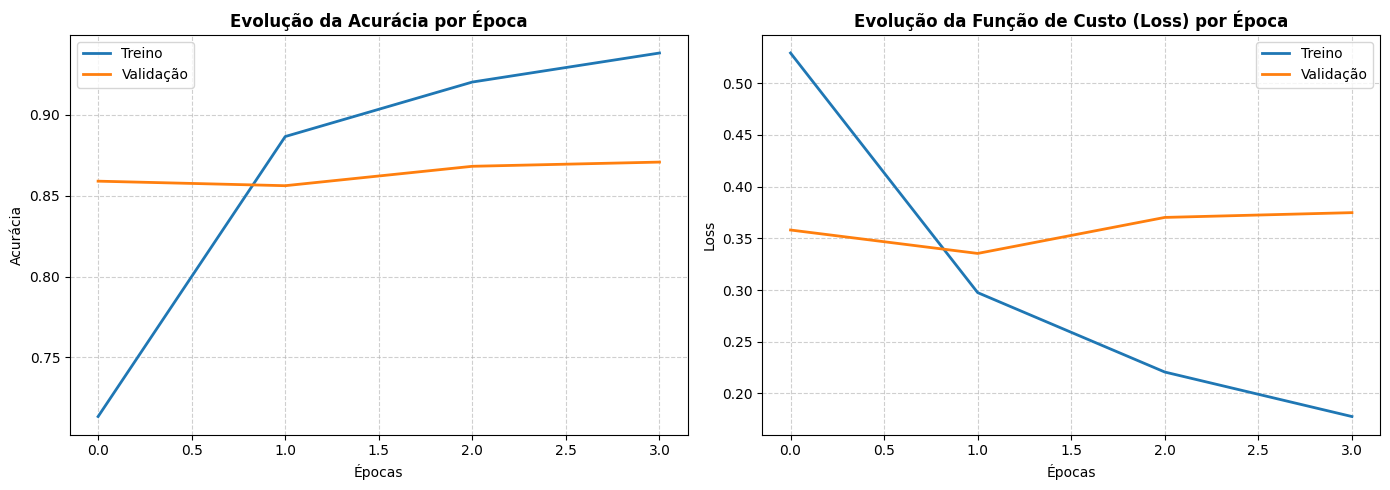

In [7]:
# Avaliação final de desempenho no conjunto de teste isolado
test_loss, test_acc = model.evaluate(x_test_pad, y_test, verbose=0)
print(f"🎯 Acurácia Geral Alcançada no Conjunto de Teste: {test_acc:.4%}\n")

# Plotagem visual das curvas de aprendizado do modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Acurácia
axes[0].plot(history.history["accuracy"], label="Treino", lw=2)
axes[0].plot(history.history["val_accuracy"], label="Validação", lw=2)
axes[0].set_title("Evolução da Acurácia por Época", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Acurácia")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

# Gráfico 2: Loss (Perda)
axes[1].plot(history.history["loss"], label="Treino", lw=2)
axes[1].plot(history.history["val_loss"], label="Validação", lw=2)
axes[1].set_title("Evolução da Função de Custo (Loss) por Época", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Épocas")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


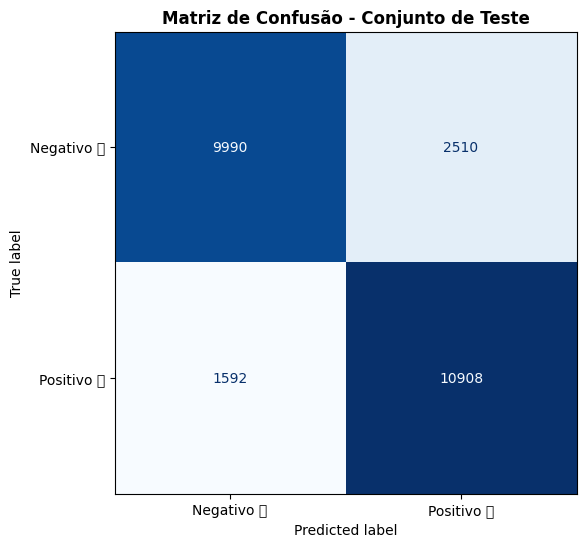


📋 Relatório Estatístico Detalhado de Classificação:

              precision    recall  f1-score   support

    Negativo       0.86      0.80      0.83     12500
    Positivo       0.81      0.87      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



In [8]:
# Geração das previsões probabilísticas para todo o conjunto de teste
y_pred_prob = model.predict(x_test_pad, verbose=0).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

# Cálculo da matriz de confusão
cm = confusion_matrix(y_test, y_pred)

# Exibição gráfica da matriz de confusão
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negativo 🔴", "Positivo 🟢"])
disp.plot(cmap="Blues", values_format="d", ax=plt.gca(), colorbar=False)
plt.title("Matriz de Confusão - Conjunto de Teste", fontsize=12, fontweight="bold")
plt.show()

# Impressão do relatório estatístico detalhado
print("\n📋 Relatório Estatístico Detalhado de Classificação:\n")
print(classification_report(y_test, y_pred, target_names=["Negativo", "Positivo"]))

---

## 💡 7. Inferência em Tempo Real com Texto Livre

Chegamos à parte mais prática e empolgante do projeto! Nesta seção, encapsulamos o modelo treinado em uma função utilitária completa.

Ela recebe uma string de **texto puro** digitada por um usuário real (simulando um feedback real de aplicativo), executa a normalização ortográfica com expressões regulares, mapeia as palavras para os códigos numéricos correspondentes no dicionário de vocabulário, aplica o preenchimento (*padding*) necessário e consulta a rede neural para retornar o veredito de sentimento acompanhado do respectivo grau de confiança estatística.

In [9]:
def texto_para_sequencia(texto, word_index, vocab_size=VOCAB_SIZE):
    """Normaliza criticamente uma string arbitrária e converte suas palavras em índices numéricos."""
    texto = texto.lower()
    texto = re.sub(r"[^a-zà-ú0-9\s]", "", texto)
    palavras = texto.split()

    sequencia = [1]  # Inclusão obrigatória do token padrão <START>
    for palavra in palavras:
        indice = word_index.get(palavra, 2)  # Retorna <UNK> (índice 2) se a palavra for desconhecida
        if indice < vocab_size:
            sequencia.append(indice)
        else:
            sequencia.append(2)
    return sequencia

def classificar_feedback(texto, modelo=model, word_index=word_index, limiar=0.5):
    """Recebe texto livre em formato de string, processa e retorna a classe e a confiança preditiva."""
    seq = texto_para_sequencia(texto, word_index)
    seq_pad = pad_sequences([seq], maxlen=MAX_LEN, padding="post", truncating="post")
    prob = float(modelo.predict(seq_pad, verbose=0)[0][0])
    classe = "POSITIVO" if prob >= limiar else "NEGATIVO"
    return {
        "feedback": texto,
        "classe": classe,
        "confianca": round(prob if classe == "POSITIVO" else 1 - prob, 4)
    }

In [12]:
# Conjunto simulado de feedbacks reais enviados por testadores de aplicativos
feedbacks_exemplo = [
    "This app is amazing, it works perfectly and the interface is super intuitive",
    "The app crashes every time I try to open the settings menu, very frustrating",
    "Love the new update, much faster than before and the design looks great",
    "Terrible experience, lost all my data after the last update",
    "It's okay I guess, does what it says but nothing special",
    "Best app I have used this year, the notifications feature is a game changer",
    "Melhor app que eu usei esse ano, as notificações são uma grande melhoria",
    "Exeperiência péssima, perdi todos os meus arquivos depois do último update",
    "App mediano. Entrega o que promete, mas de um jeito medíocre"
]

print("🚀 Resultados da Classificação em Tempo Real de Feedbacks Reais:\n")
for fb in feedbacks_exemplo:
    res = classificar_feedback(fb)
    status_emoji = "🟢" if res['classe'] == "POSITIVO" else "🔴"
    print(f"{status_emoji} [{res['classe']:8s} | Confiança do Modelo: {res['confianca']:6.2%}] ➔ \"{res['feedback']}\"")

🚀 Resultados da Classificação em Tempo Real de Feedbacks Reais:

🟢 [POSITIVO | Confiança do Modelo: 92.52%] ➔ "This app is amazing, it works perfectly and the interface is super intuitive"
🔴 [NEGATIVO | Confiança do Modelo: 61.92%] ➔ "The app crashes every time I try to open the settings menu, very frustrating"
🟢 [POSITIVO | Confiança do Modelo: 62.62%] ➔ "Love the new update, much faster than before and the design looks great"
🔴 [NEGATIVO | Confiança do Modelo: 74.90%] ➔ "Terrible experience, lost all my data after the last update"
🔴 [NEGATIVO | Confiança do Modelo: 72.28%] ➔ "It's okay I guess, does what it says but nothing special"
🟢 [POSITIVO | Confiança do Modelo: 79.11%] ➔ "Best app I have used this year, the notifications feature is a game changer"
🔴 [NEGATIVO | Confiança do Modelo: 60.11%] ➔ "Melhor app que eu usei esse ano, as notificações são uma grande melhoria"
🔴 [NEGATIVO | Confiança do Modelo: 61.22%] ➔ "Exeperiência péssima, perdi todos os meus arquivos depois do último 